<a href="https://colab.research.google.com/github/nohaelkachach/casiav2-splicing-gradcam-audit/blob/main/notebooks/02_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Feature extraction

Computes the three pre-specified measurements this study's hypotheses depend on, for all 1,828 validated spliced images:

- **splice_size_frac** — fraction of the image occupied by the tampered region (the moderator)
- **polarity** — sign of the local luminance difference between the tampered region and its immediate surround (the focal predictor)
- **abs_contrast** — magnitude of that luminance difference (control covariate, kept separate from polarity per Peli, 1990's distinction between the sign and magnitude of local contrast)

These variables were selected *before* extraction, based on the OOCS/receptive-field literature motivating this study — this is measurement construction for a pre-specified hypothesis test, not exploratory data analysis.

**Depends on:** `01_data_validation.ipynb` having been run at least once against the same Drive paths (this notebook re-derives the validated file lists independently, so it does not require notebook 1's in-memory state).

## Setup — mount Drive, rebuild validated file lists
Re-derives `spliced_files` from the authoritative list intersection, exactly as validated in notebook 1. Adjust paths if they differ from your Drive layout.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt

base = "/content/drive/MyDrive/CASIA2.0/CASIA2.0_revised"  # adjust to your actual path
au_dir = os.path.join(base, "Au")
tp_dir = os.path.join(base, "Tp")
gt_dir = "/content/drive/MyDrive/CASIA2.0/CASIA2.0_Groundtruth/CASIA2.0_Groundtruth"  # adjust if the real path differs

with open(os.path.join(base, "tp_list.txt")) as f:
    tp_list_content = [line.strip() for line in f if line.strip()]
tp_files = sorted(os.listdir(tp_dir))
tp_files_final = sorted(set(tp_list_content) & set(tp_files))

spliced_files = [f for f in tp_files_final if f.split("_")[1] == "D"]
print(f"Spliced-only file count: {len(spliced_files)}")  # expect 1828

Mounted at /content/drive
Spliced-only file count: 1828


## Mask pairing helper
Ground-truth masks in this dataset are not guaranteed to match their image's resolution — a known CASIA v2 quirk. Every function below resizes the mask to the image's own dimensions using nearest-neighbor interpolation before any pixel comparison, which preserves the mask's binary edges rather than blurring them.

In [2]:
def get_mask_path(image_filename):
    stem = os.path.splitext(image_filename)[0]
    return os.path.join(gt_dir, f"{stem}_gt.png")

## Splice size
Fraction of image pixels covered by the tampered region.

In [3]:
def compute_splice_size(mask_path, target_size=None):
    mask = Image.open(mask_path).convert("L")
    if target_size is not None:
        mask = mask.resize(target_size, Image.NEAREST)
    mask = np.array(mask)
    mask_binary = mask > 127
    return mask_binary.sum() / mask_binary.size

## Contrast polarity and magnitude
Compares the mean luminance inside the tampered region to the mean luminance of a dilated ring immediately surrounding it (not the whole image, which could include unrelated bright/dark areas far away). Polarity is positive (bright-on-dark) when the tampered region is brighter than its local surround, negative (dark-on-bright) otherwise. `abs_contrast` is the magnitude only, kept as a separate covariate from polarity's sign.

In [4]:
def compute_polarity_and_contrast(image_path, mask_path, ring_width=15):
    img_pil = Image.open(image_path).convert("L")
    img = np.array(img_pil, dtype=np.float32)

    mask_pil = Image.open(mask_path).convert("L").resize(img_pil.size, Image.NEAREST)
    mask = np.array(mask_pil)
    mask_binary = (mask > 127).astype(np.uint8)

    kernel = np.ones((ring_width, ring_width), np.uint8)
    dilated = cv2.dilate(mask_binary, kernel, iterations=1)
    surround_ring = (dilated.astype(bool)) & (~mask_binary.astype(bool))

    if surround_ring.sum() == 0 or mask_binary.sum() == 0:
        return None, None

    mean_inside = img[mask_binary.astype(bool)].mean()
    mean_surround = img[surround_ring].mean()

    contrast = mean_inside - mean_surround
    polarity = "bright_on_dark" if contrast > 0 else "dark_on_bright"
    abs_contrast = abs(contrast)

    return polarity, abs_contrast

## Run extraction over all spliced images, cache to CSV
Computed once and saved — does not need to be re-run unless the underlying image/mask set changes.

In [5]:
records = []

for i, fname in enumerate(spliced_files):
    img_path = os.path.join(tp_dir, fname)
    mask_path = get_mask_path(fname)

    if not os.path.exists(mask_path):
        continue

    img_size = Image.open(img_path).convert("L").size  # (width, height) of THIS image
    splice_size = compute_splice_size(mask_path, target_size=img_size)
    polarity, abs_contrast = compute_polarity_and_contrast(img_path, mask_path)

    if polarity is None:
        continue

    records.append({
        "filename": fname,
        "splice_size_frac": splice_size,
        "polarity": polarity,
        "abs_contrast": abs_contrast
    })

    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(spliced_files)}")

features_df = pd.DataFrame(records)
features_df.to_csv("/content/drive/MyDrive/CASIA2.0/splice_features.csv", index=False)
print(f"\nDone. Extracted features for {len(features_df)} spliced images out of {len(spliced_files)} total.")
print(features_df.head())

Processed 200/1828
Processed 400/1828
Processed 600/1828
Processed 800/1828
Processed 1000/1828
Processed 1200/1828
Processed 1400/1828
Processed 1600/1828
Processed 1800/1828

Done. Extracted features for 1828 spliced images out of 1828 total.
                                   filename  splice_size_frac        polarity  \
0  Tp_D_CND_M_N_ani00018_sec00096_00138.tif          0.369843  bright_on_dark   
1  Tp_D_CND_M_N_art00076_art00077_10289.tif          0.082448  bright_on_dark   
2  Tp_D_CND_M_N_art00077_art00076_10290.tif          0.488983  bright_on_dark   
3  Tp_D_CND_S_N_ani00073_ani00068_00193.tif          0.095052  bright_on_dark   
4  Tp_D_CND_S_N_ind00078_ind00077_00476.tif          0.053212  dark_on_bright   

   abs_contrast  
0     67.974815  
1    106.522171  
2     53.113453  
3     32.173103  
4     47.403473  


## EDA on the extracted features
Covers only splice size and polarity/contrast — IoU is not available yet, since it requires a trained classifier and Grad-CAM (notebooks 03–04). This is measurement-level description, not exploratory hypothesis-fishing: the variables and hypotheses were fixed before this data was seen.

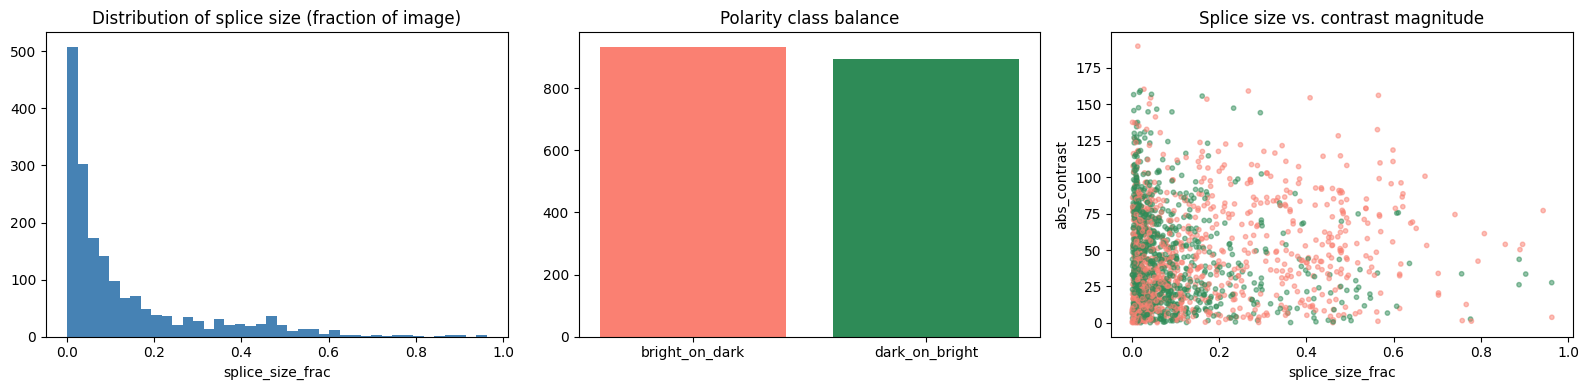


Summary stats:
       splice_size_frac  abs_contrast
count       1828.000000   1828.000000
mean           0.133120     44.844269
std            0.165919     33.299969
min            0.000483      0.072762
25%            0.021888     17.535969
50%            0.062140     38.222588
75%            0.171956     66.132786
max            0.963003    189.986511

Polarity counts:
 polarity
bright_on_dark    934
dark_on_bright    894
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(features_df["splice_size_frac"], bins=40, color="steelblue")
axes[0].set_title("Distribution of splice size (fraction of image)")
axes[0].set_xlabel("splice_size_frac")

polarity_counts = features_df["polarity"].value_counts()
axes[1].bar(polarity_counts.index, polarity_counts.values, color=["salmon", "seagreen"])
axes[1].set_title("Polarity class balance")

colors = features_df["polarity"].map({"bright_on_dark": "salmon", "dark_on_bright": "seagreen"})
axes[2].scatter(features_df["splice_size_frac"], features_df["abs_contrast"], c=colors, alpha=0.5, s=10)
axes[2].set_title("Splice size vs. contrast magnitude")
axes[2].set_xlabel("splice_size_frac")
axes[2].set_ylabel("abs_contrast")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CASIA2.0/feature_eda.png", dpi=150)
plt.show()

print("\nSummary stats:")
print(features_df[["splice_size_frac", "abs_contrast"]].describe())
print("\nPolarity counts:\n", polarity_counts)

## Confounding check — splice size vs. contrast magnitude
Verifies the moderator (size) and the control covariate (contrast magnitude) are not correlated with each other, which would otherwise make it impossible to disentangle a genuine size effect from a size-contrast confound (see Peli, 1990 on treating polarity and contrast magnitude as separable properties).

In [7]:
corr = features_df["splice_size_frac"].corr(features_df["abs_contrast"])
print(f"Correlation between splice size and contrast magnitude: {corr:.3f}")

Correlation between splice size and contrast magnitude: 0.029


## Sanity check — extracted sizes against the dataset's own size labels
CASIA filenames include an independent size-category letter (S/M/L). Cross-checking the largest/smallest computed `splice_size_frac` values against these labels is a free internal consistency check — not part of the formal analysis.

In [8]:
print(features_df.nlargest(5, "splice_size_frac")[["filename", "splice_size_frac"]])
print(features_df.nsmallest(5, "splice_size_frac")[["filename", "splice_size_frac"]])

                                     filename  splice_size_frac
367  Tp_D_NNN_L_N_ani00010_nat00095_10218.tif          0.963003
368  Tp_D_NNN_L_N_ani00010_nat00099_10217.tif          0.962697
372  Tp_D_NNN_L_O_ani00001_nat00037_00121.tif          0.943064
79   Tp_D_CRN_L_N_art00028_xxx00002_11282.jpg          0.903117
364  Tp_D_NNN_L_B_ani00070_nat00099_00190.tif          0.895935
                                      filename  splice_size_frac
1576  Tp_D_NRN_S_N_cha10148_art00092_12224.jpg          0.000483
673   Tp_D_NNN_S_N_nat10159_nat10157_12049.jpg          0.000550
1572  Tp_D_NRN_S_N_cha10134_pla00020_12202.jpg          0.000951
1709  Tp_D_NRN_S_N_nat10161_art00092_12085.jpg          0.001051
1708  Tp_D_NRN_S_N_nat10159_ani00099_12054.jpg          0.001185
